<a href="https://colab.research.google.com/github/jollyoli93/KnowYourLoadExactly/blob/main/Crane_Detector_StandardCrop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install ultralytics==8.3.190

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.9 MB/s eta 0:00:00


In [3]:
!pip install --upgrade onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.0/684.0 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 7.5 MB/s eta 0:00:00


In [4]:
!pip install wandb

In [5]:
# from wandb.integration.ultralytics import add_wandb_callback
from ultralytics import YOLO
import cv2
import numpy as np
import torch

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
%cd /content/drive/MyDrive/Crane-Detector

/content/drive/MyDrive/Crane-Detector


In [7]:
best_weights = "/content/drive/MyDrive/Crane-Detector/First Experiment/runs/obb/Best_Standard/weights/best.pt"

In [8]:
model = YOLO(best_weights)

In [9]:
test_path = "/content/drive/MyDrive/Crane-Detector/First Experiment/ALL_2CLS_NOAUG/test/images"

In [10]:
# from pathlib import Path

# results = []

# for img in Path(test_path).glob("*jpg"):
#   results.append(model.predict(img, stream=False))

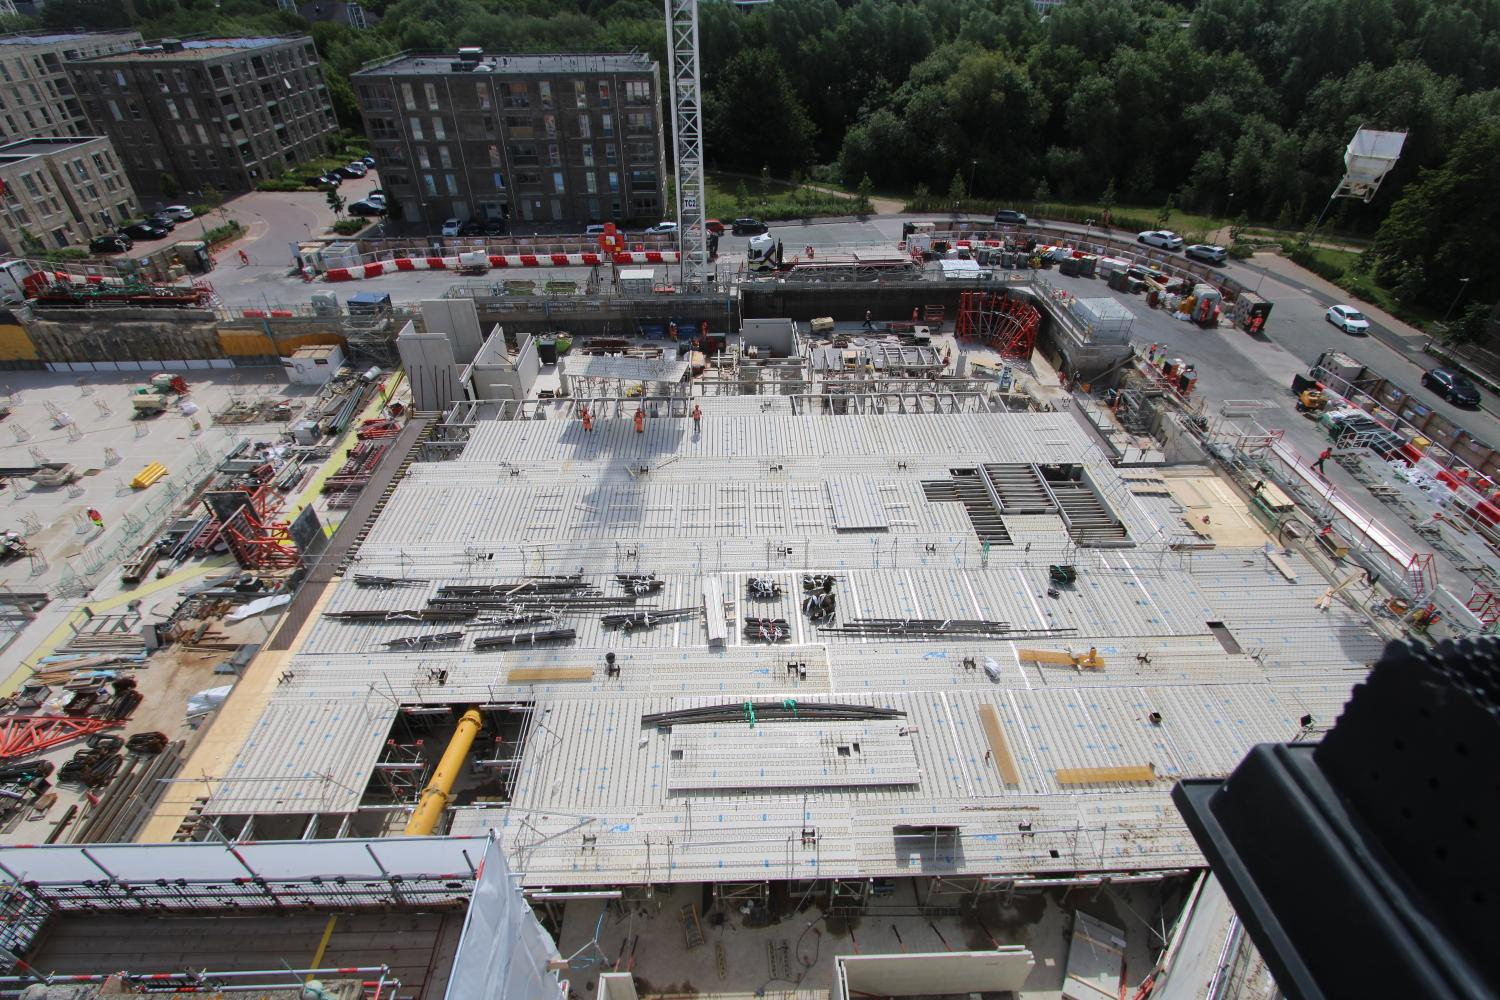

In [271]:
from google.colab.patches import cv2_imshow

# img = cv2.imread('/content/drive/MyDrive/Crane-Detector/First Experiment/All_2LCS_AUG/valid/images/2502240810060000_jpg.rf.56156243b1ad02bee4d57d2e65850cca.jpg') #1 hook, 1 load

img = cv2.imread('/content/drive/MyDrive/Crane-Detector/First Experiment/All_2LCS_AUG/test/images/2505301040060000_jpg.rf.e1ed3ff61e40b48bd7aecdf5f7df6050.jpg') #1 hook, 1 load
# img = cv2.imread('/content/drive/MyDrive/Crane-Detector/First Experiment/All_2LCS_AUG/test/images/2505301210060000_jpg.rf.4e2d4447ae977df17c79484f248ebb27.jpg') # 2 hook
# img = cv2.imread('/content/drive/MyDrive/Crane-Detector/First Experiment/All_2LCS_AUG/test/images/2505081520060000_jpg.rf.0d654dfb0aa7f32b6b1385e4ae5c7e5f.jpg')  #1 hook, 1 load
# img = cv2.imread('/content/drive/MyDrive/Crane-Detector/First Experiment/All_2LCS_AUG/test/images/2505081740060000_jpg.rf.f446e77de4d540793a42f8ff9e3e8cda.jpg')  #1 hook, 1 load real
cv2_imshow(img)


In [272]:
# Run prediction on the image
results = model.predict(img, stream=False)


0: 1088x1600 1 crane_hook, 1 crane_load, 863.1ms
Speed: 13.2ms preprocess, 863.1ms inference, 2.2ms postprocess per image at shape (1, 3, 1088, 1600)


In [273]:
results[0].obb

ultralytics.engine.results.OBB object with attributes:

cls: tensor([1., 0.])
conf: tensor([0.6935, 0.3442])
data: tensor([[1.3732e+03, 1.6008e+02, 7.5065e+01, 8.3661e+01, 3.8988e-03, 6.9354e-01, 1.0000e+00],
        [6.1136e+02, 2.3991e+02, 3.7300e+01, 2.5747e+01, 1.5694e+00, 3.4424e-01, 0.0000e+00]])
id: None
is_track: False
orig_shape: (1000, 1500)
shape: torch.Size([2, 7])
xywhr: tensor([[1.3732e+03, 1.6008e+02, 7.5065e+01, 8.3661e+01, 3.8988e-03],
        [6.1136e+02, 2.3991e+02, 3.7300e+01, 2.5747e+01, 1.5694e+00]])
xyxy: tensor([[1335.4597,  118.1047, 1410.8501,  202.0575],
        [ 598.4629,  221.2461,  624.2635,  258.5834]])
xyxyxyxy: tensor([[[1410.5239,  202.0575],
         [1410.8501,  118.3973],
         [1335.7859,  118.1047],
         [1335.4597,  201.7648]],

        [[ 598.5166,  258.5834],
         [ 624.2635,  258.5464],
         [ 624.2098,  221.2461],
         [ 598.4629,  221.2832]]])
xyxyxyxyn: tensor([[[0.9403, 0.2021],
         [0.9406, 0.1184],
         [0.89

## Load Regression Model

In [274]:
import torch

class LinearRegression(torch.nn.Module):
    def __init__(self, in_feat, out_feat, hidden) -> None:
        super().__init__()
        self.linear = torch.nn.Sequential(
            torch.nn.Linear(in_feat, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, out_feat),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        x = self.linear(x)
        return x

In [275]:
#
# cropPredict = LinearRegression(9, 2, 128)
# cropPredict.load_state_dict(torch.load("/content/drive/MyDrive/Crane-Detector/LoadRegressionModel/LoadRegressionDist", weights_only=True, map_location=torch.device('cpu')))

# cropPredict = LinearRegression(8, 2, 128)
# cropPredict.load_state_dict(torch.load("/content/drive/MyDrive/Crane-Detector/LoadRegressionModel/LoadRegressionCenter", weights_only=True, map_location=torch.device('cpu')))

cropPredict = LinearRegression(14, 2, 512)
cropPredict.load_state_dict(torch.load("/content/drive/MyDrive/Crane-Detector/LoadRegressionModel/LoadRegressionDims", weights_only=True, map_location=torch.device('cpu')))


<All keys matched successfully>

In [276]:
cropPredict.eval()

LinearRegression(
  (linear): Sequential(
    (0): Linear(in_features=14, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=2, bias=True)
    (5): Sigmoid()
  )
)

In [277]:
# def order_points(pts):
#     """
#     Orders 4 points into a consistent format:
#     [top-left, top-right, bottom-right, bottom-left]

#     Args:
#         pts (array-like): shape (4, 2) or flat list [x1, y1, ..., x4, y4]

#     Returns:
#         np.ndarray: ordered points (4, 2)
#     """
#     pts = np.array(pts, dtype="float32").reshape(4, 2)

#     # sort by y (top to bottom), then x (left to right)
#     pts = pts[np.lexsort((pts[:, 0], pts[:, 1]))]

#     # top two first, bottom two last
#     top_pts = pts[:2]
#     bottom_pts = pts[2:]

#     # order left/right for top and bottom
#     tl, tr = top_pts[np.argsort(top_pts[:, 0])]
#     bl, br = bottom_pts[np.argsort(bottom_pts[:, 0])]
#     print("returning ordered points")
#     return np.array([tl, tr, br, bl], dtype="float32")


In [278]:
def predict_load_crop(hook_coords, img_size, dims):
  img_width = img_size[1]
  img_height = img_size[0]
  print(f"Predicting new coords")

  xn = dims[0]/img_width
  yn = dims[1]/img_height
  width_n = dims[2]/img_width
  height_n = dims[3]/img_height
  area = width_n*height_n
  ratio = width_n/height_n

  input = torch.concat((hook_coords, torch.tensor([width_n]), torch.tensor([height_n]), torch.tensor([area]), torch.tensor([ratio]),
                        torch.tensor([xn]), torch.tensor([yn])), axis=0) #dims


  predict = cropPredict(input) #x, y
  img_dims = torch.tensor([img_width, img_height])
  xtens,ytens = predict*img_dims

  xc, yc = int(xtens), int(ytens)
  w , h = int(img_width*0.1), int(img_height*0.1)

  #Get top left and top right x,y
  yt = yc - (h//2)
  xt = xc - (w//2)

  print(f"Crop dims: {xt, yt, w, h}")
  return xt, yt, w, h

  # return standard_size #Return top left and bottom right to crop

In [283]:
def crop_load(img, x, y, w, h):
  """
    Takes as input, top left corner, width and height.
  """
  crop_img = img.copy()

  # xt, yt, xb,yb = results[0].obb[0].cpu().xyxy.numpy()[0].astype(int)
  # w, h = results[0].obb[0].cpu().xywhr.numpy()[0].astype(int)[2:4]
  cropped_img = crop_img[y:y+h,x:x+w]

  return cropped_img
  # print(x, y, w, h)
  # cv2_imshow(cropped_img)

Class: crane_load, Box: [1335  118 1410  202]


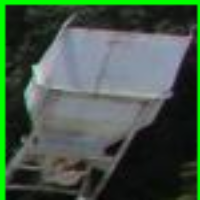

Class: crane_hook, Box: [598 221 624 258]
crane_hook
tensor([0.3990, 0.2586, 0.4162, 0.2585, 0.4161, 0.2212, 0.3990, 0.2213])
(1000, 1500)
Dims tensor([611.3632, 239.9148,  37.3003,  25.7470,   1.5694])
Predicting new coords
Crop dims: (537, 336, 150, 100)


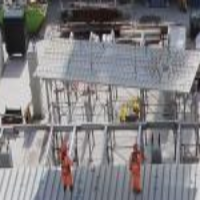

In [296]:
# Iterate over the results

for result in results:
    boxes = result.obb.cpu()  # Get boxes on CPU in numpy format
    for box in boxes:  # Iterate over boxes
        r = box.xyxy[0].numpy() .astype(int) # Get corner points as int (Actual Co-ords)
        class_id = int(box.cls[0])  # Get class ID
        class_name = model.names[class_id]  # Get class name using the class ID
        conf = float(box.conf[0])
        print(f"Class: {class_name}, Box: {r}")  # Print class name and box coordinates
        label = f"{class_name}: {conf:.2f}"

        # Get predicted co-ordinates if not load detected

        if class_id == 0: #Hook Class
          coords = box.xyxyxyxyn[0].flatten() #Get all coordinates for prediction
          print(class_name)
          print(coords)
          print(box.orig_shape)
          dims = box.xywhr[0]
          print(f"Dims {dims}")

          pts = predict_load_crop(coords, box.orig_shape, dims)
          xt, yt, w, h = pts
          crop = crop_load(img, xt,yt,w,h)
          crop_resized = cv2.resize(crop, (200, 200))
          cv2_imshow(crop_resized)
          # cv2.drawMarker(img, (int(pts[0]), int(pts[1])), color=[0, 0, 0], thickness=10,
          #   markerType= cv2.MARKER_TILTED_CROSS, line_type=cv2.LINE_AA,
          #   markerSize=100)

        if class_id == 1: #Load Class
          xt, yt, xb, yb = r
          w, h = box.xywhr.numpy()[0].astype(int)[2:4]
          crop = crop_load(img, xt,yt,w,h)
          crop_resized = cv2.resize(crop, (200, 200))
          cv2_imshow(crop_resized)
          #classify

        cv2.rectangle(img, r[:2], r[2:], (0, 255, 0), 2)  # Draw YOLO boxes on the image

        font = cv2.FONT_HERSHEY_SIMPLEX
        cv2.putText(img, label,(r[0], r[1]-10), font, 0.8,(255,255,255),2,cv2.LINE_AA)

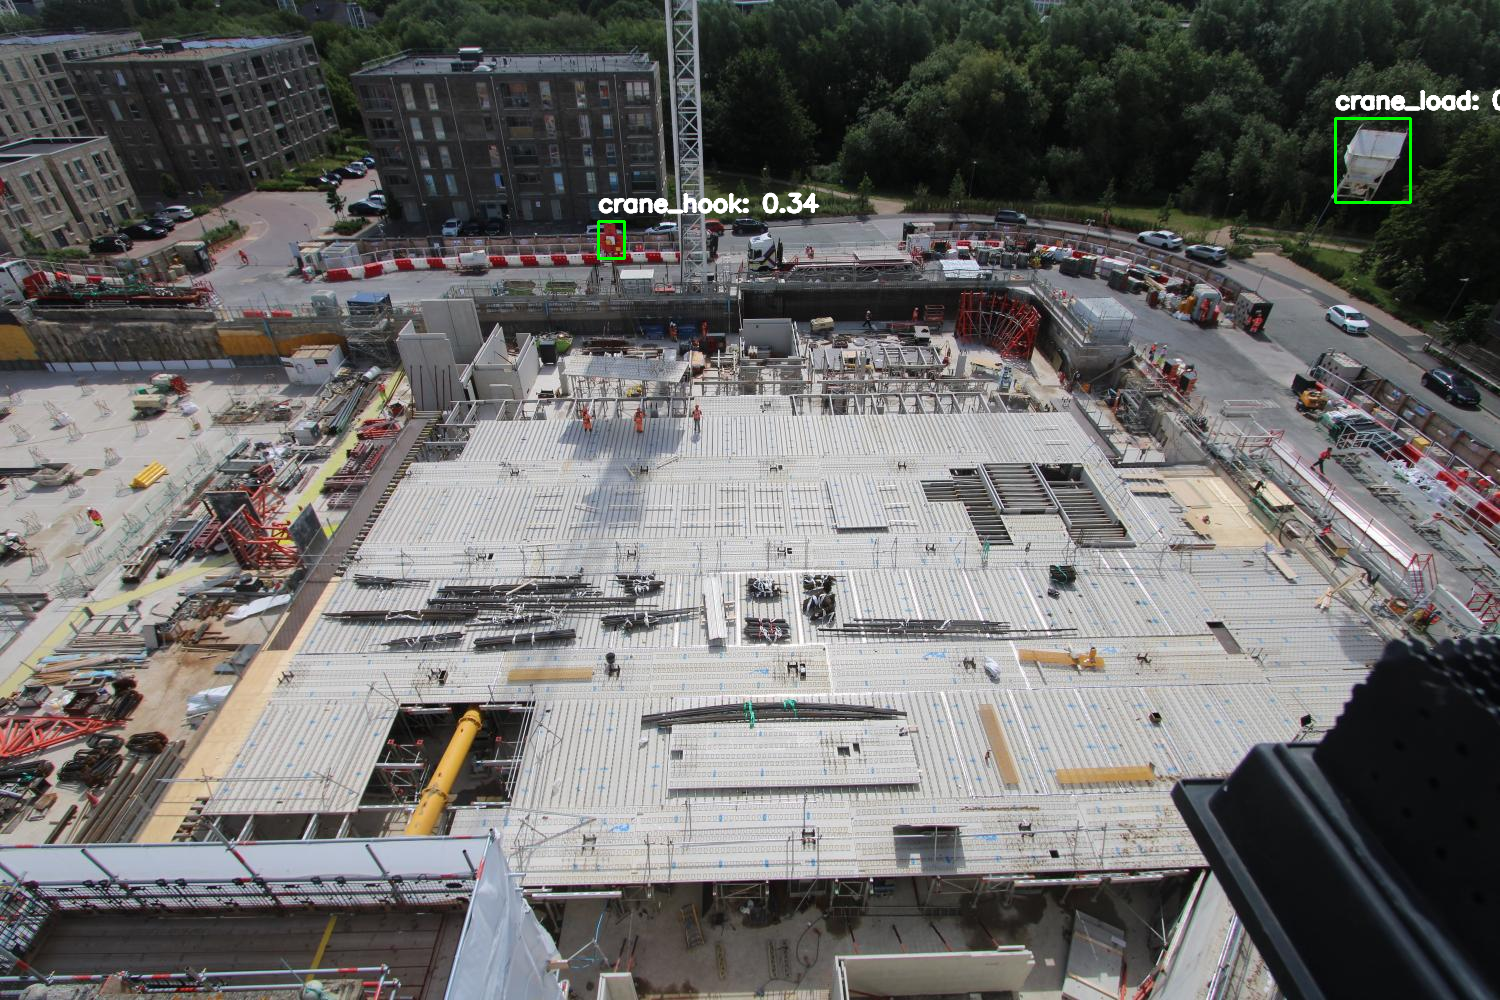

In [291]:
cv2_imshow(img)


## CV2 Practise

In [140]:
img = cv2.imread('/content/drive/MyDrive/Crane-Detector/First Experiment/All_2LCS_AUG/test/images/2505301040060000_jpg.rf.e1ed3ff61e40b48bd7aecdf5f7df6050.jpg') #1 hook, 1 load

In [141]:
# Get cropped load
xt, yt, xb,yb = results[0].obb[0].cpu().xyxy.numpy()[0].astype(int)
w, h = results[0].obb[0].cpu().xywhr.numpy()[0].astype(int)[2:4]
cropped_img = img[yt:yt+h,xt:xt+75]

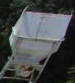

In [158]:
cv2_imshow(cropped_img)

## Crop load

In [27]:
img_h, img_w = result.orig_shape

In [28]:
#COORD are in columns (y) and rows (x) so start is 0,0 - Bottom Left is 1000,0 etc
#Set Y values
top_of_crop = y+(h//2)+h
depth_of_crop = top_of_crop + (h*5)

#Set X values
start_of_crop = x-w*5
width_of_crop = start_of_crop + (w*10)

In [29]:
cropped_in_half = img[top_of_crop:depth_of_crop, start_of_crop:width_of_crop]

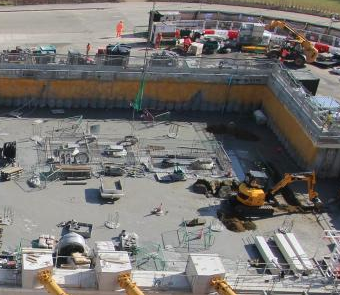

In [30]:
cv2_imshow(cropped_in_half)